# Exploring the Logistics and Supply Chain Dataset

**Course module:** Module 8
**Audience:** Beginners who want to understand real-world logistics telemetry before building models or knowledge graphs

## Course description

Modern supply chains generate **continuous streams of data**: vehicle GPS, warehouse stock, traffic,
weather, supplier performance, and risk scores. Before applying machine learning or graph analytics,
you need to know **what each field means** and **how variables relate to one another**.

In this hands-on course you will:

1. Load and inspect the **Dynamic Supply Chain Logistics** CSV dataset.
2. Learn the **business meaning** of every column, grouped by operational domain.
3. Run **exploratory visualizations** to see distributions, trends, and relationships.
4. Review **real-world use cases** where this data supports predictive and optimization workflows.

> **Language:** All instructional text is in **English**.

### How to use this notebook

1. Read **every markdown cell** before running the code cell below it.
2. Run cells **in order** from Step 0 downward.
3. After each plot or table, read the **interpretation** markdown that follows.
4. Code cells are intentionally **short**; markdown explains the *why*, *how*, and *what to notice*.
5. Plots appear inline — if figures are empty, re-run the cell or ensure `%matplotlib inline` is active.


## Prerequisites

| Skill | Why you need it |
|-------|-----------------|
| Basic Python | Run notebook cells |
| pandas fundamentals | `read_csv`, `describe`, grouping |
| (Helpful) logistics vocabulary | Trucks, warehouses, lead time, ETA |

### Dataset

| File | Description |
|------|-------------|
| `data/logistics-supply-chain/dynamic_supply_chain_logistics_dataset.csv` | Hourly logistics telemetry (Kaggle, CC0-1.0) |

**Source:** [Kaggle — Logistics and supply chain dataset](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset)

- **Rows:** ~32,000 hourly observations
- **Time span:** January 2021 — August 2024
- **Granularity:** One row per timestamp (simulated fleet / network snapshot)

## Course outline

| Part | Topic | Learning goal |
|------|--------|---------------|
| **0** | Environment setup | Install libraries and locate the CSV |
| **1** | Load the data | Confirm shape, columns, and types |
| **2** | Field dictionary | Understand every column by domain |
| **3** | Data quality | Check missing values and ranges |
| **4** | Time patterns | See how activity changes over hours and months |
| **5** | Location & movement | Map GPS coverage and fuel use |
| **6** | Traffic, ETA & delays | Link congestion to delivery deviation |
| **7** | Warehouse & fulfillment | Inventory vs demand signals |
| **8** | Weather & ports | External disruption factors |
| **9** | Suppliers & costs | Upstream reliability and economics |
| **10** | IoT, cargo & routes | Cold-chain and route risk |
| **11** | Driver & fatigue scores | Human-factor monitoring |
| **12** | Risk & classification | Target variables for ML |
| **13** | Correlation overview | Which metrics move together |
| **14** | Use cases (reading) | Where this dataset fits in practice |
| **15** | Wrap-up | Next steps in Module 8 |


---

# Step 0 — Environment setup

Before exploring data, we prepare a reproducible Python environment. This part has **no logistics
analysis yet** — only tooling. Skipping setup cells often causes confusing `ModuleNotFoundError`
messages later.


### Step 0a — Install Python packages

**What this cell does:** Installs libraries for data loading and visualization using pip.

| Package | Role in this course |
|---------|---------------------|
| `pandas` | Load CSV, compute statistics, group by time |
| `matplotlib` | Line charts, histograms, bar plots |
| `seaborn` | Regression plots, heatmaps, styled scatter plots |
| `cartopy` | North America map background and projected GPS scatter plots (Part 5) |

**When to run:** Once per virtual environment (conda, venv, or system Python).

**Expected output:** Pip may print nothing (`-q` quiet mode). That is normal.

> **Troubleshooting:** If `cartopy` fails to install via pip, try `conda install -c conda-forge cartopy`.
> For other errors, activate your course virtual environment first, then re-run.


In [1]:
# Step 0a — Install dependencies (run once per environment)
%pip install -q pandas matplotlib seaborn cartopy



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Step 0b — Import libraries and set plot style

**What this cell does:** Imports core libraries and configures display defaults for the whole notebook.

**Key operations explained:**

| Line | Purpose |
|------|---------|
| `sns.set_theme(...)` | Consistent chart colors and grid for all seaborn plots |
| `plt.rcParams['figure.figsize']` | Default plot size so figures are readable without resizing |
| `pd.set_option('display.max_columns', None)` | Show all 26 columns when previewing tables |
| `pd.set_option('display.float_format', ...)` | Round floats to 3 decimals for cleaner tables |

**Expected output:** `Libraries loaded successfully.`

> **Note:** `Path` from `pathlib` helps build file paths that work on Windows, macOS, and Linux.


In [2]:
# Step 0b — Imports and display settings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print('Libraries loaded successfully.')


Libraries loaded successfully.


**After running Step 0b:** No plots yet. Confirm the success message printed. If you see
`ModuleNotFoundError`, return to Step 0a.


### Step 0c — Resolve paths to the dataset

**What this cell does:** Locates `Module_8/` and builds the absolute path to the CSV file.

**Why path logic matters:** Jupyter may start in the repo root *or* inside `Module_8/`. The `if not ...`
block detects when you opened the notebook from the parent folder and adjusts `MODULE_DIR` automatically.

**Variables you will reuse:**

| Variable | Meaning |
|----------|---------|
| `MODULE_DIR` | Root folder for Module 8 labs |
| `DATA_PATH` | Full path to the logistics CSV |

**Expected output:**

- `File exists: True` — you are ready to load data.
- `File exists: False` — download the CSV per `data/DATASETS.md`.


In [3]:
# Step 0c — Dataset path
MODULE_DIR = Path('.').resolve()
if not (MODULE_DIR / 'data').exists() and (MODULE_DIR.parent / 'Module_8' / 'data').exists():
    MODULE_DIR = MODULE_DIR.parent / 'Module_8'

DATA_PATH = MODULE_DIR / 'data' / 'logistics-supply-chain' / 'dynamic_supply_chain_logistics_dataset.csv'
print(f'Module directory: {MODULE_DIR}')
print(f'Dataset path:     {DATA_PATH}')
print(f'File exists:      {DATA_PATH.exists()}')


Module directory: /home/ethan/newgen/KMOU_Course/Module_8
Dataset path:     /home/ethan/newgen/KMOU_Course/Module_8/data/logistics-supply-chain/dynamic_supply_chain_logistics_dataset.csv
File exists:      True


**After running Step 0c:** If `File exists` is `False`, stop here and download the dataset.
Do not continue to Part 1 until the CSV is on disk.


---

# Part 1 — Load the dataset

We now read the CSV into a pandas **DataFrame** called `df`. This is the central object for the rest
of the notebook. Every chart and table below reads from `df`.


### Step 1a — Read the CSV into a DataFrame

**What this cell does:**

1. `pd.read_csv(DATA_PATH)` — loads all rows and columns from disk.
2. `pd.to_datetime(df['timestamp'])` — converts the timestamp column from text to proper datetime.
3. Prints row count, column count, and the earliest/latest timestamps.

**What you should notice:**

- Each row is an **hourly snapshot** of logistics operations.
- There are **26 columns** spanning vehicles, warehouses, suppliers, risk, and outcomes.
- The date range should span roughly **2021-01-01** through **2024-08-29**.

**Expected output:**

```
Rows:    32,065
Columns: 26
Date range: 2021-01-01 00:00:00 → 2024-08-29 00:00:00
```


In [4]:
# Step 1a — Load CSV
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'Rows:    {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')


Rows:    32,065
Columns: 26
Date range: 2021-01-01 00:00:00 → 2024-08-29 00:00:00


**How to interpret Step 1a:**

- **32,065 rows** means ~3.7 years of hourly readings (some hours may repeat across vehicles/regions in this synthetic set).
- **26 columns** is relatively wide — typical for IoT + ERP + TMS merged exports.
- Parsing `timestamp` early unlocks time-based plots in Part 4.


### Step 1b — Preview the first rows

**What this cell does:** Displays `df.head()` — the first five rows — as an interactive table.

**How to read the preview:**

| Question | Columns to scan |
|----------|-----------------|
| Where is the vehicle? | `vehicle_gps_latitude`, `vehicle_gps_longitude` |
| Is stock low? | `warehouse_inventory_level` vs `historical_demand` |
| Is this hour risky? | `risk_classification`, `delay_probability` |
| Any external stress? | `traffic_congestion_level`, `weather_condition_severity` |

**Expected output:** A 5-row table. Scroll horizontally if columns are truncated in your Jupyter theme.


In [5]:
# Step 1b — Head preview
df.head()


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.376,-77.014,5.137,4.998,5.928,985.717,4.951,0.481,0.761,0.359,4.289,456.504,0.986,2.128,100.773,0.574,0.777,1.182,0.502,0.034,0.979,0.506,0.885,Moderate Risk,9.111
1,2021-01-01 01:00:00,33.508,-117.037,5.102,0.985,1.592,396.700,1.030,0.621,0.197,0.231,7.018,640.408,0.463,12.608,"5,313.738",-9.753,0.092,9.612,0.967,0.202,0.919,0.981,0.544,High Risk,8.175
2,2021-01-01 02:00:00,30.021,-75.269,5.091,4.973,8.788,832.409,4.220,0.811,0.153,0.027,9.605,155.749,0.599,14.124,"1,595.049",-6.491,0.254,6.570,0.946,0.264,0.394,0.999,0.803,High Risk,1.284
3,2021-01-01 03:00:00,36.649,-70.191,8.220,3.095,0.045,0.573,0.530,0.009,0.812,0.617,8.900,104.318,0.743,3.819,"2,530.432",-0.151,0.878,0.549,4.674,0.363,0.905,0.993,0.026,High Risk,9.305
4,2021-01-01 04:00:00,30.001,-70.012,5.000,3.216,8.005,914.925,3.621,0.020,0.054,0.952,0.062,977.223,0.431,14.001,"2,146.190",2.429,0.262,8.861,3.445,0.017,0.259,0.912,0.991,High Risk,7.752


**After Step 1b — reflection questions:**

1. Do GPS coordinates look like plausible US lat/long values (latitude ~30–50, longitude negative)?
2. Are `risk_classification` values one of: Low Risk, Moderate Risk, High Risk?
3. Which numeric columns appear bounded between 0 and 1?


### Step 1c — Column names and data types

**What this cell does:** Builds a small schema table listing every column, its pandas dtype, and non-null count.

**Why this matters before modeling:**

- `float64` columns are continuous features.
- `object` columns (here: `timestamp` before parsing was object; after parsing `risk_classification` remains categorical text) need encoding for ML.
- `non_null` equal to row count confirms **no missing values**.

**Expected output:** A 26-row table with columns `column`, `dtype`, `non_null`.


In [6]:
# Step 1c — Schema overview
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null': df.notna().sum().values,
})
schema


,column,dtype,non_null
0,timestamp,datetime64[us],32065
1,vehicle_gps_latitude,float64,32065
2,vehicle_gps_longitude,float64,32065
3,fuel_consumption_rate,float64,32065
4,eta_variation_hours,float64,32065
5,traffic_congestion_level,float64,32065
6,warehouse_inventory_level,float64,32065
7,loading_unloading_time,float64,32065
8,handling_equipment_availability,float64,32065
9,order_fulfillment_status,float64,32065


**How to interpret Step 1c:**

- `timestamp` should show `datetime64` after Step 1a.
- `risk_classification` stays `object` — treat it as a **category** in analysis.
- If any `non_null` is less than 32,065, note which column has gaps before training models.


---

# Part 2 — Field dictionary (what each column means)

The dataset merges signals from **fleet telematics**, **warehouse systems**, **port operations**,
**supplier records**, and **risk engines**. Below we group columns by operational domain.

> **Note on scales:** Many columns are normalized to continuous scales (often roughly 0–10 or 0–1).
> Treat them as **relative indices** unless your organization maps them to physical units.

## 2.1 — Time and location

| Column | Type | Meaning |
|--------|------|---------|
| `timestamp` | datetime | Hour when the observation was recorded |
| `vehicle_gps_latitude` | float | Vehicle latitude (degrees, ~30–50°N in this sample) |
| `vehicle_gps_longitude` | float | Vehicle longitude (degrees, mostly US corridor) |

**Why it matters:** GPS enables route tracking, geofencing, and regional aggregation.

## 2.2 — Vehicle performance

| Column | Type | Meaning |
|--------|------|---------|
| `fuel_consumption_rate` | float | Fuel burn rate index (higher → more consumption / inefficiency) |

**Why it matters:** Supports cost control, carbon reporting, and predictive maintenance triggers.

## 2.3 — Traffic, ETA, and delivery outcomes

| Column | Type | Meaning |
|--------|------|---------|
| `traffic_congestion_level` | float | Road congestion index (higher → slower traffic) |
| `eta_variation_hours` | float | Change vs planned ETA in hours (+ late, − early) |
| `delivery_time_deviation` | float | Actual vs planned delivery time gap (target outcome) |
| `delay_probability` | float | Modelled probability of delay (0–1) |

**Why it matters:** Core inputs for routing optimization and on-time performance dashboards.

## 2.4 — Warehouse and order fulfillment

| Column | Type | Meaning |
|--------|------|---------|
| `warehouse_inventory_level` | float | Stock on hand (units in warehouse) |
| `loading_unloading_time` | float | Time spent at dock (hours or normalized hours) |
| `handling_equipment_availability` | float | Share of forklifts / loaders available (0–1) |
| `order_fulfillment_status` | float | Fulfillment progress or success rate (0–1) |
| `historical_demand` | float | Past demand signal used for replenishment planning |

**Why it matters:** Links upstream inventory decisions to downstream delivery performance.

## 2.5 — Weather and port congestion

| Column | Type | Meaning |
|--------|------|---------|
| `weather_condition_severity` | float | Weather disruption index (storms, snow, heat, etc.) |
| `port_congestion_level` | float | Port / terminal backlog index |

**Why it matters:** External shocks that propagate through multimodal supply chains.

## 2.6 — Economics and suppliers

| Column | Type | Meaning |
|--------|------|---------|
| `shipping_costs` | float | Cost index or USD-like cost for the shipment leg |
| `supplier_reliability_score` | float | Historical on-time / quality score (0–1, higher is better) |
| `lead_time_days` | float | Supplier lead time in days |

**Why it matters:** Procurement and network design trade-offs between cost, speed, and reliability.

## 2.7 — IoT, cargo, and customs

| Column | Type | Meaning |
|--------|------|---------|
| `iot_temperature` | float | Cargo temperature from IoT sensor (°C; cold-chain monitoring) |
| `cargo_condition_status` | float | Cargo integrity index (0–1, higher → better condition) |
| `route_risk_level` | float | Geopolitical / safety / infrastructure risk along route |
| `customs_clearance_time` | float | Time spent in customs (hours or normalized) |

**Why it matters:** Compliance, spoilage prevention, and cross-border delay management.

## 2.8 — Driver monitoring

| Column | Type | Meaning |
|--------|------|---------|
| `driver_behavior_score` | float | Safe-driving score from telematics (0–1) |
| `fatigue_monitoring_score` | float | Fatigue / drowsiness index (0–1) |

**Why it matters:** Human factors contribute significantly to accident and delay risk.

## 2.9 — Risk and disruption (targets for ML)

| Column | Type | Meaning |
|--------|------|---------|
| `disruption_likelihood_score` | float | Composite score: chance of major disruption |
| `delay_probability` | float | Probability of shipment delay |
| `risk_classification` | category | **Low Risk**, **Moderate Risk**, or **High Risk** |
| `delivery_time_deviation` | float | Regression target — magnitude of schedule slip |

**Why it matters:** These are typical **labels** or **targets** for classification and regression models.


### Step 2a — Print a quick reference grouped by domain

**What this cell does:** Defines a Python dictionary `FIELD_GROUPS` that mirrors the tables above,
then prints each domain and its columns to the console.

**Why code a dictionary:**

- Beginners can **re-run** this cell as a cheat sheet while scrolling through later parts.
- The same grouping can be reused in ML feature selection or graph schema design.

**Expected output:** Nine sections printed (`Time & location`, `Vehicle`, … `Risk & disruption`).


In [7]:
# Step 2a — Domain-grouped field reference
FIELD_GROUPS = {
    'Time & location': ['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude'],
    'Vehicle': ['fuel_consumption_rate'],
    'Traffic & delivery': [
        'traffic_congestion_level', 'eta_variation_hours',
        'delivery_time_deviation', 'delay_probability',
    ],
    'Warehouse & fulfillment': [
        'warehouse_inventory_level', 'loading_unloading_time',
        'handling_equipment_availability', 'order_fulfillment_status', 'historical_demand',
    ],
    'Weather & ports': ['weather_condition_severity', 'port_congestion_level'],
    'Suppliers & costs': ['shipping_costs', 'supplier_reliability_score', 'lead_time_days'],
    'IoT, cargo & customs': [
        'iot_temperature', 'cargo_condition_status',
        'route_risk_level', 'customs_clearance_time',
    ],
    'Driver monitoring': ['driver_behavior_score', 'fatigue_monitoring_score'],
    'Risk & disruption': [
        'disruption_likelihood_score', 'delay_probability',
        'risk_classification',
    ],
}

for domain, cols in FIELD_GROUPS.items():
    print(f'\n=== {domain} ===')
    for c in cols:
        print(f'  - {c}')



=== Time & location ===
  - timestamp
  - vehicle_gps_latitude
  - vehicle_gps_longitude

=== Vehicle ===
  - fuel_consumption_rate

=== Traffic & delivery ===
  - traffic_congestion_level
  - eta_variation_hours
  - delivery_time_deviation
  - delay_probability

=== Warehouse & fulfillment ===
  - warehouse_inventory_level
  - loading_unloading_time
  - handling_equipment_availability
  - order_fulfillment_status
  - historical_demand

=== Weather & ports ===
  - weather_condition_severity
  - port_congestion_level

=== Suppliers & costs ===
  - shipping_costs
  - supplier_reliability_score
  - lead_time_days

=== IoT, cargo & customs ===
  - iot_temperature
  - cargo_condition_status
  - route_risk_level
  - customs_clearance_time

=== Driver monitoring ===
  - driver_behavior_score
  - fatigue_monitoring_score

=== Risk & disruption ===
  - disruption_likelihood_score
  - delay_probability
  - risk_classification


**After Step 2a:** You now have both **static tables** (markdown above) and a **printable cheat sheet**.
In Part 3 we validate that the data behind these fields is complete and numerically sensible.


---

# Part 3 — Data quality checks

Exploratory analysis should always include a **quality pass** before visualization or modeling.
We check for missing values, unrealistic ranges, and overall distributions.


### Step 3a — Missing values

**What this cell does:**

1. `df.isna().sum()` counts nulls per column.
2. Filters to columns with at least one missing value.
3. Prints a friendly message if the dataset is complete.

**Why missing data matters in logistics:**

- Missing GPS → cannot map routes.
- Missing IoT temperature → cold-chain compliance blind spots.
- Missing supplier scores → procurement risk models degrade.

**Expected output:** `No missing values — all 26 columns are complete.`


In [8]:
# Step 3a — Missing value counts
missing = df.isna().sum()
missing_df = missing[missing > 0]
if missing_df.empty:
    print('No missing values — all 26 columns are complete.')
else:
    display(missing_df)


No missing values — all 26 columns are complete.


**After Step 3a:** A complete CSV simplifies teaching but is **not typical in production**.
Real pipelines often have 5–15% sensor dropout. Always re-run this check after joining new sources.


### Step 3b — Numeric summary statistics

**What this cell does:** Calls `df.describe().T` to transpose the summary so **each row is a column**.

**How to read the statistics:**

| Statistic | Logistics interpretation |
|-----------|-------------------------|
| `min` / `max` | Are values physically plausible? (e.g., lat 30–50) |
| `mean` | Central tendency — compare across risk groups later |
| `std` | Variability — low std may mean normalized or stable process |
| `50%` (median) | Robust center; compare to mean to detect skew |

**Expected output:** A wide table with ~8 statistic rows per numeric column.


In [9]:
# Step 3b — Summary statistics
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,32065,2022-10-31 00:00:00,2021-01-01 00:00:00,2021-12-01 00:00:00,2022-10-31 00:00:00,2023-09-30 00:00:00,2024-08-29 00:00:00,NaN
vehicle_gps_latitude,"32,065.000",38.024,30.000,31.281,36.414,44.454,50.000,6.918
vehicle_gps_longitude,"32,065.000",-90.117,-120.000,-106.254,-86.293,-73.079,-70.000,17.369
fuel_consumption_rate,"32,065.000",8.012,5.000,5.020,5.636,9.670,20.000,4.265
eta_variation_hours,"32,065.000",2.893,-2.000,1.186,3.882,4.884,5.000,2.274
traffic_congestion_level,"32,065.000",4.991,0.000,1.475,4.981,8.535,10.000,3.532
warehouse_inventory_level,"32,065.000",299.255,0.000,16.052,157.288,540.598,999.999,323.444
loading_unloading_time,"32,065.000",2.292,0.500,0.775,1.917,3.734,5.000,1.554
handling_equipment_availability,"32,065.000",0.303,0.000,0.017,0.160,0.554,1.000,0.326
order_fulfillment_status,"32,065.000",0.601,0.000,0.277,0.681,0.938,1.000,0.346


**Spot-check suggestions for Step 3b:**

- `warehouse_inventory_level` max near 1000 — aligns with inventory unit scale.
- `supplier_reliability_score` between 0 and 1 — probability-like score.
- `iot_temperature` spans negative and positive °C — refrigerated vs ambient cargo.


### Step 3c — Visualize distributions of key numeric fields

**What this cell does:** Draws a 2×3 grid of histograms for six representative columns.

**Why these six columns:**

| Column | Domain represented |
|--------|-------------------|
| `warehouse_inventory_level` | Warehouse |
| `traffic_congestion_level` | Traffic |
| `delay_probability` | Risk / outcome |
| `supplier_reliability_score` | Supplier |
| `fuel_consumption_rate` | Vehicle |
| `delivery_time_deviation` | Delivery outcome |

**How to read histograms:**

- **Single peak** → values cluster around a typical operating point.
- **Flat / uniform** → synthetic or evenly sampled feature.
- **Long tail** → occasional extreme events (delays, congestion spikes).

**Expected output:** One figure with six subplots.


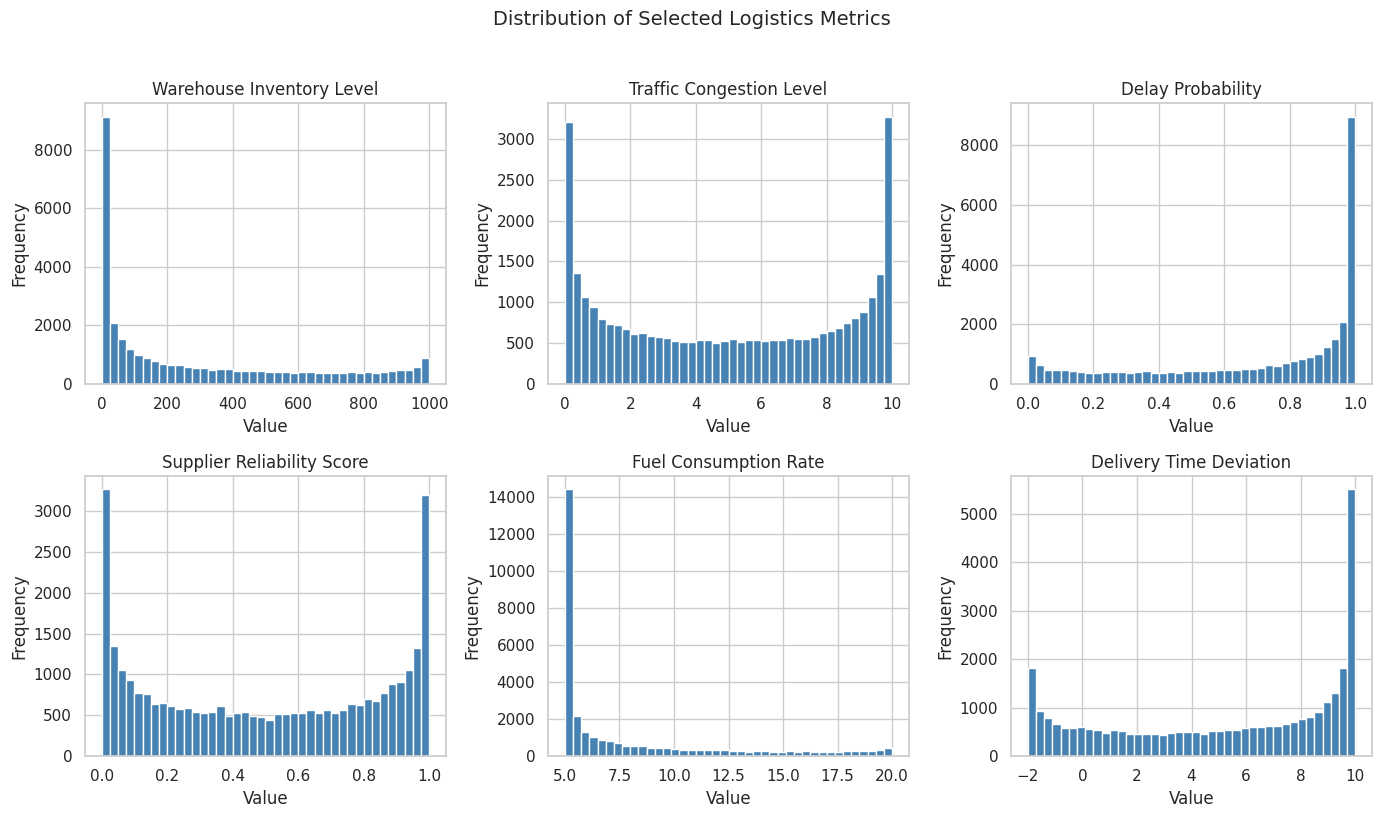

In [10]:
# Step 3c — Distribution histograms
sample_cols = [
    'warehouse_inventory_level',
    'traffic_congestion_level',
    'delay_probability',
    'supplier_reliability_score',
    'fuel_consumption_rate',
    'delivery_time_deviation',
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, sample_cols):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Selected Logistics Metrics', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**After Step 3c:** Note which features look **uniform** vs **skewed**. Skewed targets like
`delivery_time_deviation` may need log transforms or robust loss functions in regression models.


---

# Part 4 — Time patterns

Logistics performance often varies by **hour of day** (rush hour), **day of week** (weekend closures),
and **season** (weather, holidays). We derive calendar features from `timestamp` to expose these patterns.


### Step 4a — Add calendar features

**What this cell does:** Creates three new columns:

| New column | How it is computed | Example use |
|------------|-------------------|-------------|
| `hour` | `timestamp.dt.hour` | Peak-hour congestion analysis |
| `day_of_week` | `timestamp.dt.day_name()` | Weekend vs weekday fulfillment |
| `month` | `to_period('M')` as string | Monthly trend charts |

**Expected output:** A 5-row preview showing original timestamp plus derived fields.

> **Note:** These features are **engineered** — not in the raw CSV — but standard in time-series EDA.


In [11]:
# Step 4a — Calendar features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.to_period('M').astype(str)

df[['timestamp', 'hour', 'day_of_week', 'month']].head()


,timestamp,hour,day_of_week,month
0,2021-01-01 00:00:00,0,Friday,2021-01
1,2021-01-01 01:00:00,1,Friday,2021-01
2,2021-01-01 02:00:00,2,Friday,2021-01
3,2021-01-01 03:00:00,3,Friday,2021-01
4,2021-01-01 04:00:00,4,Friday,2021-01


**After Step 4a:** The DataFrame now has 29 columns (26 original + 3 derived).
Subsequent groupby operations use `hour` and `month` without re-parsing timestamps.


### Step 4b — Average delay probability by hour of day

**What this cell does:**

1. Groups all rows by `hour` (0–23).
2. Computes the **mean** `delay_probability` per hour.
3. Plots a line chart with markers.

**Business question:** *Are certain hours systematically riskier for delays?*

**How to read the chart:**

- **Upward slope during business hours** → congestion-driven delay risk.
- **Flat line** → delay risk may be driven by non-time factors in this synthetic set.
- Compare peaks to warehouse shift changes and port operating windows.

**Expected output:** Line chart with x-axis 0–23 and y-axis mean delay probability.


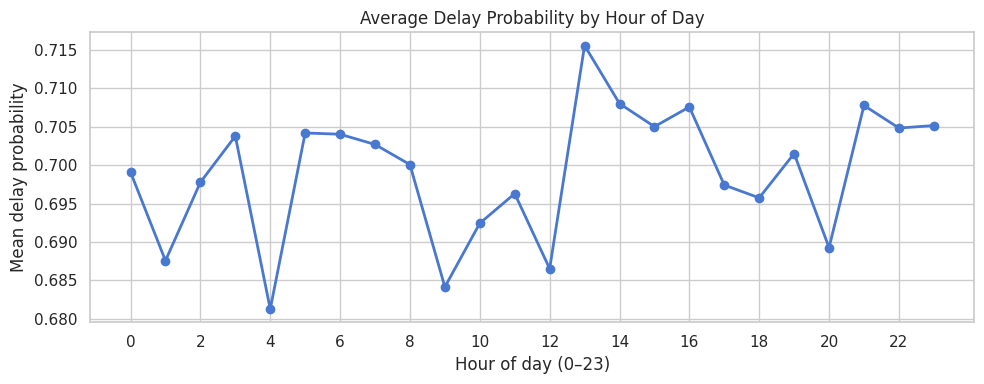

In [12]:
# Step 4b — Delay probability by hour
hourly_delay = df.groupby('hour')['delay_probability'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(hourly_delay['hour'], hourly_delay['delay_probability'], marker='o', linewidth=2)
plt.xlabel('Hour of day (0–23)')
plt.ylabel('Mean delay probability')
plt.title('Average Delay Probability by Hour of Day')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


**Interpretation prompt:** Identify the hour with the **highest** mean delay probability.
Would staffing more drivers at that hour reduce delays, or is the cause external (weather, ports)?


### Step 4c — Monthly trend of delivery time deviation

**What this cell does:** Aggregates `delivery_time_deviation` by `month` and plots a time-series line.

**Why monthly aggregation:**

- Hourly data is noisy — monthly means reveal **slow drifts** (policy changes, fuel prices).
- Helps leadership see multi-year performance, not single-hour spikes.

**How to read the chart:**

- **Rising trend** → systemic schedule slippage worsening over time.
- **Seasonal waves** → repeating yearly patterns (weather, holidays).
- **Sudden jumps** → investigate data generation changes or real disruptions.

**Expected output:** Line chart with ~44 monthly points (2021-01 through 2024-08).


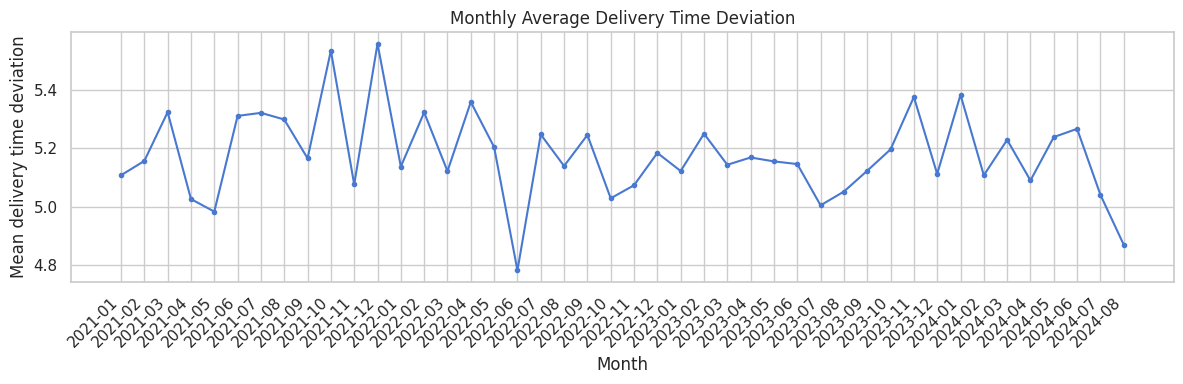

In [13]:
# Step 4c — Monthly delivery deviation trend
monthly_dev = df.groupby('month')['delivery_time_deviation'].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(monthly_dev['month'], monthly_dev['delivery_time_deviation'], marker='.', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('Mean delivery time deviation')
plt.title('Monthly Average Delivery Time Deviation')
plt.tight_layout()
plt.show()


**After Part 4:** You can articulate whether delay risk varies by **time of day** and whether delivery
deviation **drifts across months**. Next we map **where** vehicles operate and how **fuel** relates to traffic.


---

# Part 5 — Location and vehicle performance

Fleet telematics combine **GPS position** with **fuel metrics**. This part visualizes geographic spread
and the relationship between road conditions and fuel consumption.


### Step 5a — GPS scatter plot on a North America map (sampled)

**What this cell does:**

1. Randomly samples **3,000 rows** (`random_state=42` for reproducibility).
2. Computes the GPS bounding box from the full dataset and **zooms the map to North America**.
3. Draws a regional map background (land, ocean, coastlines, US state borders) using `cartopy`.
4. Overlays vehicle positions from `vehicle_gps_longitude` (x) and `vehicle_gps_latitude` (y).
5. Colors each point by `fuel_consumption_rate` (yellow–orange–red = higher).

**Why zoom instead of a world map:** All GPS points in this CSV fall in North America. Cropping
removes empty oceans and continents so freight corridors are easier to see.

**Key geospatial concepts:**

| Concept | In this notebook |
|---------|------------------|
| `PlateCarree()` | Standard lon/lat projection (x = longitude, y = latitude) |
| `transform=ccrs.PlateCarree()` | Tells cartopy that scatter coordinates are raw GPS degrees |
| `set_extent([west, east, south, north], ...)` | Crop the map to the GPS coverage area |

**Why sample:** 32,000 points overlap and slow rendering. Sampling preserves spatial pattern.

**How to read the map:**

- Points should fall on **land or near coasts** — not in the middle of oceans (sanity check).
- **Cluster bands** → common freight corridors across the US and southern Canada.
- **Red hotspots** → high fuel burn locations (hills, urban idling, detours).

**Expected output:** North America map zoomed to GPS coverage, with colorbar labeled *Fuel consumption rate*.


Map extent (west, east, south, north): [-122.0, -68.0, 28.0, 52.0]


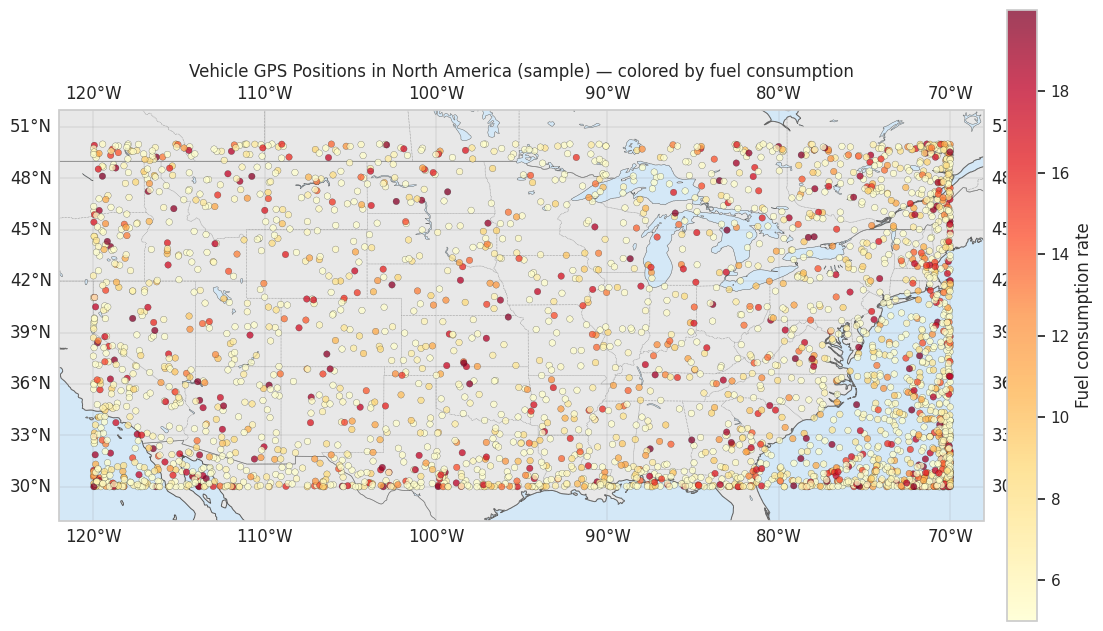

In [14]:
# Step 5a — GPS scatter on North America map colored by fuel consumption
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sample = df.sample(n=3000, random_state=42)

# Crop map to where GPS points actually appear (North America) + small margin
lon_pad, lat_pad = 2.0, 2.0
na_extent = [
    df['vehicle_gps_longitude'].min() - lon_pad,
    df['vehicle_gps_longitude'].max() + lon_pad,
    df['vehicle_gps_latitude'].min() - lat_pad,
    df['vehicle_gps_latitude'].max() + lat_pad,
]
print(f'Map extent (west, east, south, north): {[round(v, 2) for v in na_extent]}')

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(na_extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#d4e8f7', zorder=0)
ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='#555555', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, edgecolor='#666666', zorder=1)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.4, edgecolor='#999999', zorder=1)
ax.add_feature(cfeature.LAKES, facecolor='#d4e8f7', edgecolor='#555555', linewidth=0.3, zorder=1)

gl = ax.gridlines(
    draw_labels=True,
    dms=False,
    x_inline=False,
    y_inline=False,
    linewidth=0.3,
    color='gray',
    alpha=0.5,
)

sc = ax.scatter(
    sample['vehicle_gps_longitude'],
    sample['vehicle_gps_latitude'],
    c=sample['fuel_consumption_rate'],
    cmap='YlOrRd',
    alpha=0.75,
    s=22,
    edgecolors='k',
    linewidths=0.2,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Fuel consumption rate')
ax.set_title('Vehicle GPS Positions in North America (sample) — colored by fuel consumption')

plt.tight_layout()
plt.show()


**After Step 5a:** The printed `na_extent` shows the longitude/latitude window used for cropping.
Zooming to that box removes empty map area and makes **freight corridors** across the US and Canada easier to read.

**Extension idea (no code):** Bin GPS into **regions** or **h3 hexagons** and compare mean delay
probability per region — a common geospatial feature for routing models.


### Step 5b — Fuel consumption vs traffic congestion (enhanced joint plot)

**What this cell does:** Builds a **joint plot** with three visual layers:

| Layer | Chart element | What it tells you |
|-------|---------------|-------------------|
| **Center** | Hexbin heatmap (`YlOrRd`) | Where most (traffic, fuel) pairs cluster — brighter = more rows |
| **Center** | Dashed navy trend line | Overall direction of the relationship (regression) |
| **Top** | Traffic histogram + KDE | How congestion levels are distributed |
| **Right** | Fuel histogram + KDE | How fuel consumption is distributed |

**Hypothesis:** Higher `traffic_congestion_level` → more idling and stop-and-go → higher fuel burn.

**How to read this chart:**

1. Start with the **marginal** plots — understand each variable alone.
2. Look at the **hexbin** center — follow the brightest cells (densest region).
3. Check the **trend line** — upward slope supports the traffic → fuel hypothesis.

**Expected output:** Large joint figure with colorbar *Number of observations*.


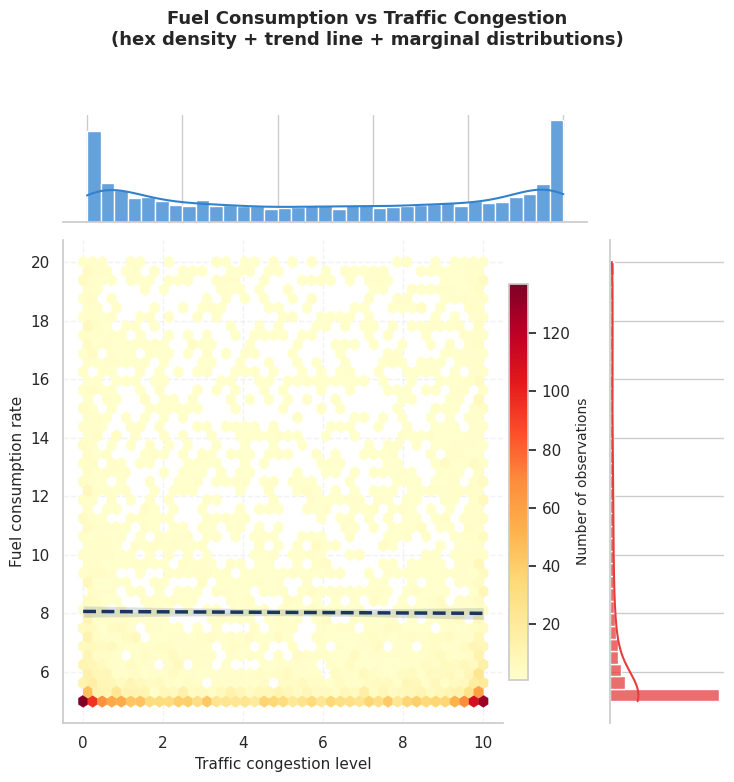

In [15]:
# Step 5b — Fuel vs traffic (hexbin joint plot + trend + marginals)
fuel_traffic = df.sample(n=5000, random_state=42)

g = sns.JointGrid(
    data=fuel_traffic,
    x='traffic_congestion_level',
    y='fuel_consumption_rate',
    height=7.5,
    ratio=4,
    space=0.08,
)

hexbin = g.ax_joint.hexbin(
    fuel_traffic['traffic_congestion_level'],
    fuel_traffic['fuel_consumption_rate'],
    gridsize=42,
    cmap='YlOrRd',
    mincnt=1,
    linewidths=0.25,
    edgecolors='face',
)
cbar = g.fig.colorbar(hexbin, ax=g.ax_joint, shrink=0.82, pad=0.01)
cbar.set_label('Number of observations', fontsize=10)

sns.regplot(
    data=fuel_traffic,
    x='traffic_congestion_level',
    y='fuel_consumption_rate',
    ax=g.ax_joint,
    scatter=False,
    color='#1a365d',
    line_kws={'linewidth': 2.5, 'linestyle': '--'},
)

sns.histplot(
    data=fuel_traffic,
    x='traffic_congestion_level',
    ax=g.ax_marg_x,
    kde=True,
    color='#3182ce',
    alpha=0.75,
    edgecolor='white',
    bins=35,
)
sns.histplot(
    data=fuel_traffic,
    y='fuel_consumption_rate',
    ax=g.ax_marg_y,
    kde=True,
    color='#e53e3e',
    alpha=0.75,
    edgecolor='white',
    bins=35,
)

g.ax_joint.set_xlabel('Traffic congestion level', fontsize=11)
g.ax_joint.set_ylabel('Fuel consumption rate', fontsize=11)
g.ax_joint.grid(True, alpha=0.25, linestyle='--')
g.fig.suptitle(
    'Fuel Consumption vs Traffic Congestion\n'
    '(hex density + trend line + marginal distributions)',
    y=1.04,
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()


**How to interpret Step 5b:**

- **Bright hex cells** in the center mark the most common operating conditions.
- If the **dashed line** slopes upward, congestion and fuel use tend to rise together.
- **Marginal KDE curves** (smooth lines on top/right) show whether values cluster at low, mid, or high levels.

**After Part 5:** Fuel and traffic are inputs for **predictive maintenance** and **green logistics**
initiatives. Part 6 zooms into **delivery delays** directly.


---

# Part 6 — Traffic, ETA, and delays

This part focuses on **on-time performance**: how traffic and ETA updates relate to delay probability
and actual delivery deviation. These columns are central to routing optimization use cases.

> **Shared sample:** Step 6b creates `plot_sample` (4,000 rows) reused in Parts 6–13 for consistent scatter plots.


### Step 6a — Traffic congestion distribution

**What this cell does:** Histogram of `traffic_congestion_level` across all 32,065 rows.

**Why start with a univariate view:** Before correlating traffic with outcomes, understand whether
congestion is usually low, usually high, or uniformly spread.

**Expected output:** Single histogram — x-axis = congestion index, y-axis = frequency.


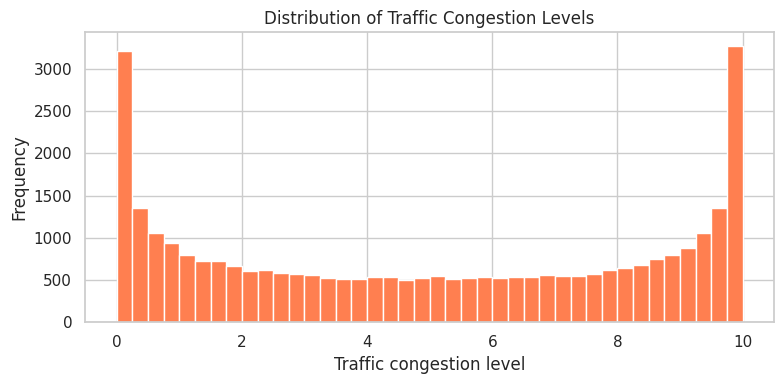

In [16]:
# Step 6a — Traffic congestion histogram
plt.figure(figsize=(8, 4))
plt.hist(df['traffic_congestion_level'], bins=40, color='coral', edgecolor='white')
plt.xlabel('Traffic congestion level')
plt.ylabel('Frequency')
plt.title('Distribution of Traffic Congestion Levels')
plt.tight_layout()
plt.show()


**After Step 6a:** If the distribution is roughly uniform, congestion may be synthetically sampled rather
than derived from real traffic APIs — still valid for teaching relationships.


### Step 6b — Traffic congestion vs delivery time deviation

**What this cell does:**

1. Creates `plot_sample = df.sample(4000, random_state=7)` for lighter scatter plots.
2. Uses `sns.regplot` — scatter points **plus** a linear regression trend line.

**Columns used:**

| Axis | Column | Meaning |
|------|--------|---------|
| x | `traffic_congestion_level` | Road congestion index |
| y | `delivery_time_deviation` | Schedule slip magnitude |

**How to read regplot:**

- **Upward sloping red line** → higher congestion associated with larger deviations.
- **Flat line** → weak linear link (non-linear models may still help).
- **Wide scatter** → other factors dominate individual deliveries.

**Expected output:** Scatter with semi-transparent points and dark red trend line.


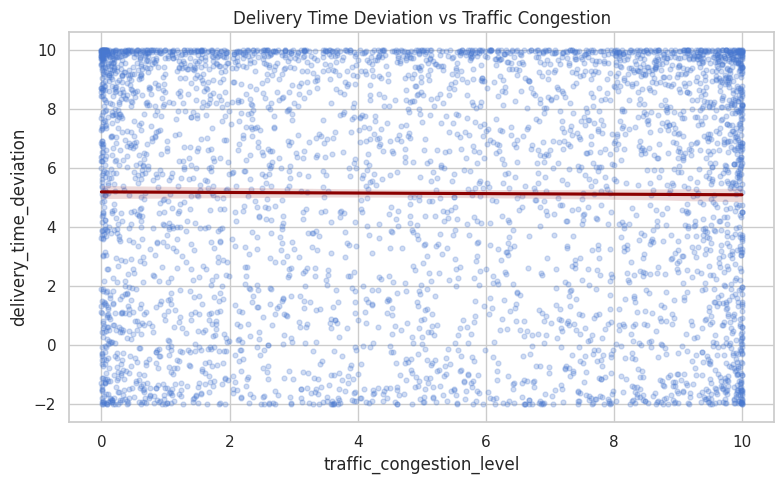

In [17]:
# Step 6b — Traffic vs delivery deviation
plot_sample = df.sample(n=4000, random_state=7)

plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='traffic_congestion_level',
    y='delivery_time_deviation',
    scatter_kws={'alpha': 0.25, 's': 12},
    line_kws={'color': 'darkred'},
)
plt.title('Delivery Time Deviation vs Traffic Congestion')
plt.tight_layout()
plt.show()


**Business takeaway:** If congestion correlates with deviation, route optimizers should penalize
high-traffic edges during dispatch — a core VRP (vehicle routing problem) constraint.


### Step 6c — ETA variation vs delay probability

**What this cell does:** Scatter plot of `eta_variation_hours` (x) vs `delay_probability` (y).

**Field reminder:**

- `eta_variation_hours` — positive values mean the ETA was **pushed later** vs plan.
- `delay_probability` — model-estimated chance of missing the committed delivery window.

**Question to answer visually:** When planners already revised ETA upward, is delay probability also high?

**Expected output:** Cloud of points; look for upward trend in dense regions.


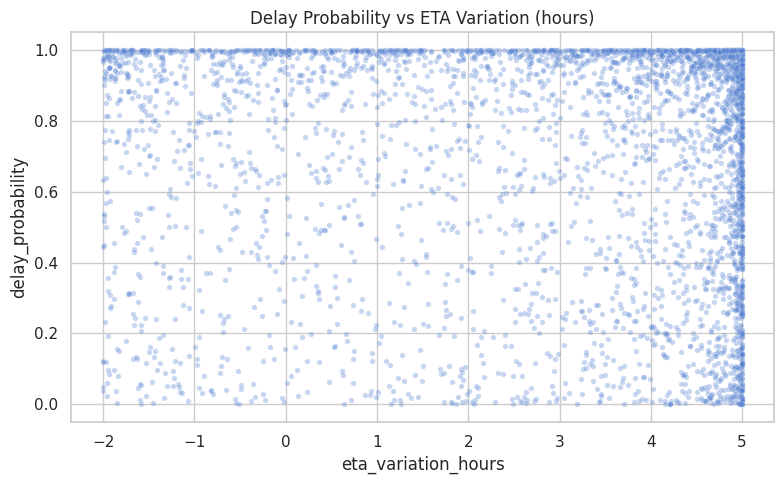

In [18]:
# Step 6c — ETA variation vs delay probability
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='eta_variation_hours',
    y='delay_probability',
    alpha=0.3,
    s=15,
)
plt.title('Delay Probability vs ETA Variation (hours)')
plt.tight_layout()
plt.show()


**After Part 6:** You have explored the **traffic → delay** story from three angles: distribution,
delivery deviation, and ETA updates. Part 7 shifts to **warehouse and fulfillment** signals.


---

# Part 7 — Warehouse and fulfillment

Warehouse operations connect **inventory**, **demand**, **dock efficiency**, and **order fulfillment**.
Poor stock positioning or equipment shortages upstream often surface as delivery risk downstream.


### Step 7a — Inventory level vs historical demand

**What this cell does:** Scatter plot with:

| Aesthetic | Column | Role |
|-----------|--------|------|
| x-axis | `historical_demand` | How much customers wanted historically |
| y-axis | `warehouse_inventory_level` | Stock currently on hand |
| color | `order_fulfillment_status` | Fulfillment success (viridis: yellow→green) |

**How to interpret clusters:**

- Points **below** the diagonal band (low inventory vs high demand) → stockout risk.
- **Green** points with low inventory → possible expedited fulfillment or backorders.
- **Purple** points with high inventory → potential overstock or slow movers.

**Expected output:** Color-coded scatter — *Warehouse Inventory vs Historical Demand*.


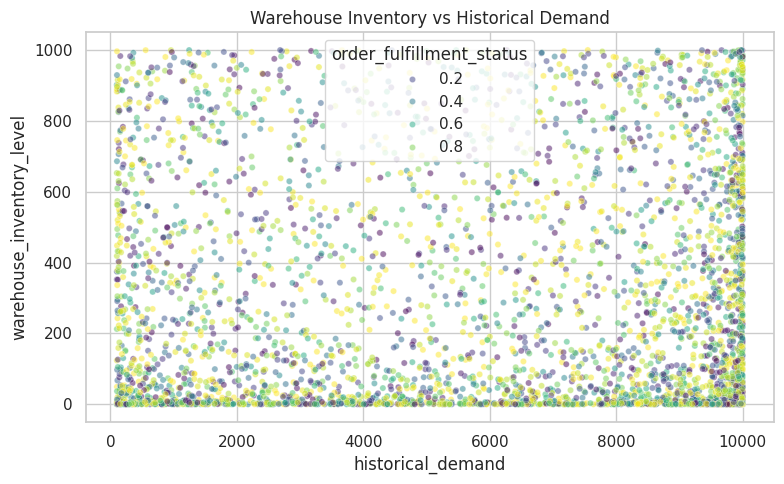

In [19]:
# Step 7a — Inventory vs demand scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='historical_demand',
    y='warehouse_inventory_level',
    hue='order_fulfillment_status',
    palette='viridis',
    alpha=0.5,
    s=20,
)
plt.title('Warehouse Inventory vs Historical Demand')
plt.tight_layout()
plt.show()


**Link to Module 8:** Continue with `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb`
to model warehouses, demand, and risk as a **Neo4j knowledge graph**.


### Step 7b — Equipment availability vs loading/unloading time

**What this cell does:** `sns.regplot` of `handling_equipment_availability` (x) vs `loading_unloading_time` (y).

**Operational story:** Forklifts and dock doors are **capacity constraints**. When availability drops,
trailers wait longer — increasing `loading_unloading_time` and cascading to missed ETAs.

**Expected trend:** Negative slope — less equipment → longer dock times.

**Expected output:** Scatter + regression line.


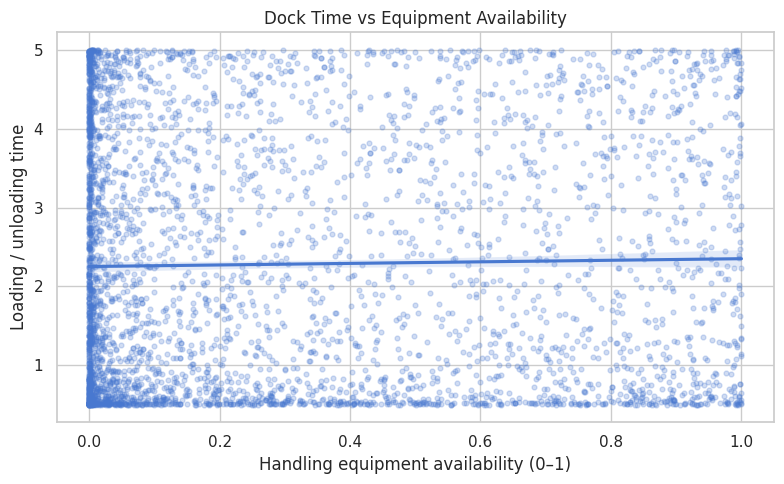

In [20]:
# Step 7b — Equipment availability vs dock time
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='handling_equipment_availability',
    y='loading_unloading_time',
    scatter_kws={'alpha': 0.25, 's': 12},
)
plt.xlabel('Handling equipment availability (0–1)')
plt.ylabel('Loading / unloading time')
plt.title('Dock Time vs Equipment Availability')
plt.tight_layout()
plt.show()


**Actionable insight:** Maintenance scheduling for handling equipment is a **controllable lever** —
unlike weather or port strikes.


### Step 7c — Order fulfillment status by risk class

**What this cell does:**

1. Groups by `risk_classification`.
2. Computes mean `order_fulfillment_status` per class.
3. Draws a horizontal bar chart (green / orange / red).
4. Prints the numeric table below the chart.

**Question:** Do High Risk hours also show lower fulfillment on average?

**Expected output:** Bar chart + small Series table.


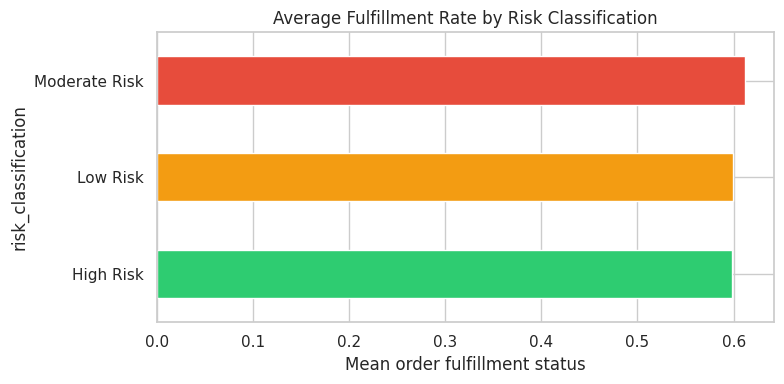

risk_classification
High Risk       0.599
Low Risk        0.599
Moderate Risk   0.611
Name: order_fulfillment_status, dtype: float64

In [21]:
# Step 7c — Fulfillment by risk classification
fulfillment_by_risk = df.groupby('risk_classification')['order_fulfillment_status'].mean().sort_values()

plt.figure(figsize=(8, 4))
fulfillment_by_risk.plot(kind='barh', color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.xlabel('Mean order fulfillment status')
plt.title('Average Fulfillment Rate by Risk Classification')
plt.tight_layout()
plt.show()
fulfillment_by_risk


**After Part 7:** Warehouse metrics explain **upstream** causes of customer-facing delay risk.
Part 8 examines **external** factors: weather and ports.


---

# Part 8 — Weather and port congestion

Multimodal supply chains hand off freight between **trucks**, **ports**, and **rails**. Weather and
terminal backlog are classic **exogenous** variables — hard to control, critical to forecast.


### Step 8a — Side-by-side distributions

**What this cell does:** Two histograms in one row:

| Subplot | Column | Color |
|---------|--------|-------|
| Left | `weather_condition_severity` | Sky blue |
| Right | `port_congestion_level` | Slate blue |

**Why compare distributions together:** Both are external stress indices — seeing their shapes side by side
helps you judge whether they are similarly scaled before correlating them with delays.

**Expected output:** 1×2 figure with two histograms.


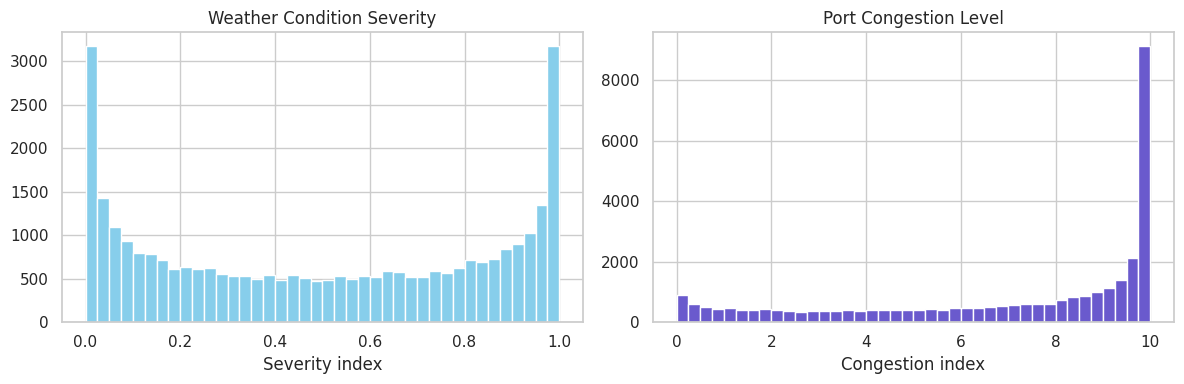

In [22]:
# Step 8a — Weather and port congestion distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['weather_condition_severity'], bins=40, color='skyblue', edgecolor='white')
axes[0].set_title('Weather Condition Severity')
axes[0].set_xlabel('Severity index')

axes[1].hist(df['port_congestion_level'], bins=40, color='slateblue', edgecolor='white')
axes[1].set_title('Port Congestion Level')
axes[1].set_xlabel('Congestion index')

plt.tight_layout()
plt.show()


**Reflection:** Which index shows more extreme tail events? Tail risk often drives insurance and
contingency routing policies.


### Step 8b — Weather severity vs delivery time deviation

**What this cell does:**

1. `pd.cut(..., bins=5)` splits weather severity into **five equal-width bins**.
2. Computes mean `delivery_time_deviation` per bin.
3. Plots a bar chart.

**Why bin instead of scatter:** Weather effects are often **non-linear** — extreme storms matter more than
light rain. Binning exposes step changes beginners can see clearly.

**How to read bars:** Rising bar heights from left to right → worse weather aligns with larger deviations.

**Expected output:** Bar chart with five weather bins on x-axis.


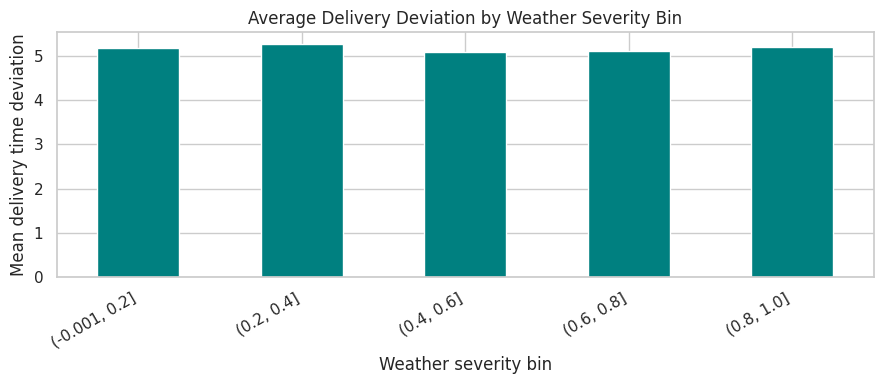

In [23]:
# Step 8b — Weather impact on delivery deviation
weather_bins = pd.cut(df['weather_condition_severity'], bins=5)
weather_impact = df.groupby(weather_bins, observed=True)['delivery_time_deviation'].mean()

plt.figure(figsize=(9, 4))
weather_impact.plot(kind='bar', color='teal', edgecolor='white')
plt.xlabel('Weather severity bin')
plt.ylabel('Mean delivery time deviation')
plt.title('Average Delivery Deviation by Weather Severity Bin')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Further reading (no code):** Join this dataset with [NOAA weather feeds](https://www.ncei.noaa.gov/)
in production to replace synthetic severity with measured precipitation and wind.


---

# Part 9 — Suppliers, lead time, and shipping costs

Upstream supplier performance influences whether warehouses receive stock on time. This part explores
**reliability scores**, **lead times**, and **shipping economics**.


### Step 9a — Supplier reliability distribution

**What this cell does:** Histogram of `supplier_reliability_score` (0 = unreliable, 1 = highly reliable).

**Procurement context:** Organizations often tier suppliers (A/B/C) using such scores for allocation
of purchase orders and safety-stock rules.

**Expected output:** Distribution centered somewhere between 0 and 1 — note skew toward low or high reliability.


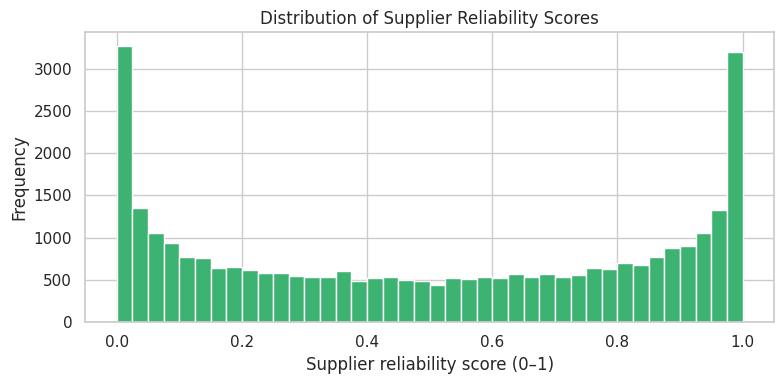

In [24]:
# Step 9a — Supplier reliability histogram
plt.figure(figsize=(8, 4))
plt.hist(df['supplier_reliability_score'], bins=40, color='mediumseagreen', edgecolor='white')
plt.xlabel('Supplier reliability score (0–1)')
plt.ylabel('Frequency')
plt.title('Distribution of Supplier Reliability Scores')
plt.tight_layout()
plt.show()


**Question:** If many suppliers cluster below 0.5 reliability, network design may need dual-sourcing.


### Step 9b — Lead time vs shipping costs

**What this cell does:** Scatter of `lead_time_days` (x) vs `shipping_costs` (y).

**Trade-off to discuss in class:**

- **Air freight** — short lead time, high cost.
- **Ocean freight** — long lead time, lower cost per unit.

Look for whether longer lead times associate with lower shipping costs in this synthetic data.

**Expected output:** Scatter cloud — 4,000 points from `plot_sample`.


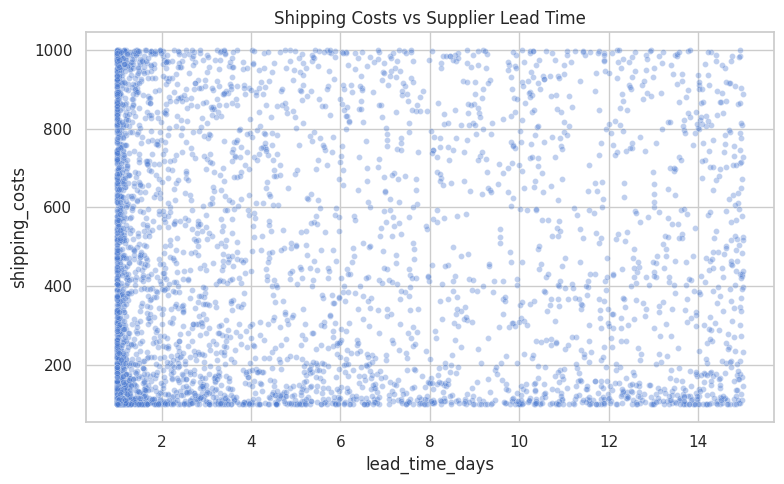

In [25]:
# Step 9b — Lead time vs shipping costs
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='lead_time_days',
    y='shipping_costs',
    alpha=0.35,
    s=18,
)
plt.title('Shipping Costs vs Supplier Lead Time')
plt.tight_layout()
plt.show()


**After Step 9b:** Procurement dashboards often plot this as a **efficient frontier** — Pareto-optimal
choices between speed and cost.


### Step 9c — Supplier reliability vs disruption likelihood

**What this cell does:** Regression plot linking `supplier_reliability_score` to `disruption_likelihood_score`.

**Hypothesis:** Unreliable suppliers increase network-wide disruption risk (stockouts, expedite fees, line stoppages).

**Expected trend:** Negative slope — higher reliability → lower disruption likelihood.

**Expected output:** Purple trend line with scatter points.


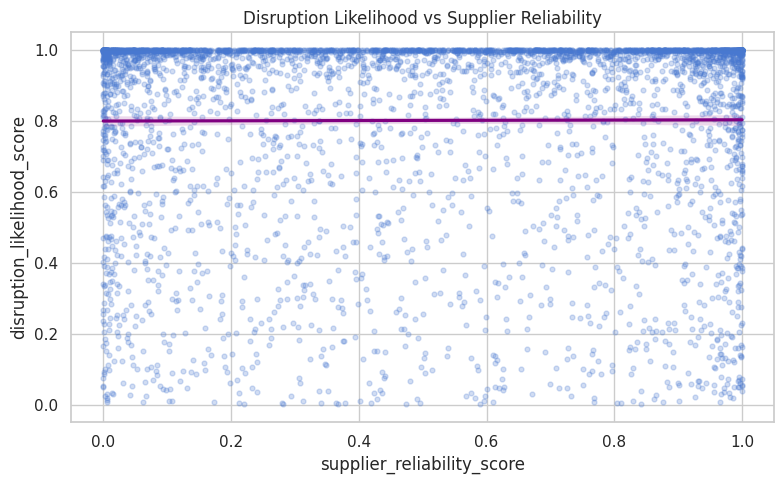

In [26]:
# Step 9c — Reliability vs disruption score
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='supplier_reliability_score',
    y='disruption_likelihood_score',
    scatter_kws={'alpha': 0.25, 's': 12},
    line_kws={'color': 'purple'},
)
plt.title('Disruption Likelihood vs Supplier Reliability')
plt.tight_layout()
plt.show()


**After Part 9:** Supplier metrics feed **risk classification** models explored in Part 12.


---

# Part 10 — IoT temperature, cargo condition, and route risk

Cold-chain and high-value cargo require **sensor monitoring** and **route risk assessment**.
Customs delays add friction at international borders.


### Step 10a — IoT temperature distribution (cold-chain)

**What this cell does:** Histogram of `iot_temperature` with a **red dashed line at 0°C** as reference.

**Cold-chain primer:**

| Temperature zone | Typical goods |
|------------------|---------------|
| Below 0°C | Frozen foods, certain vaccines |
| 2–8°C | Refrigerated pharmaceuticals |
| Ambient | General merchandise |

**Alert logic (conceptual):** Values far outside the safe band for a product class trigger QA holds.

**Expected output:** Histogram spanning negative to positive °C.


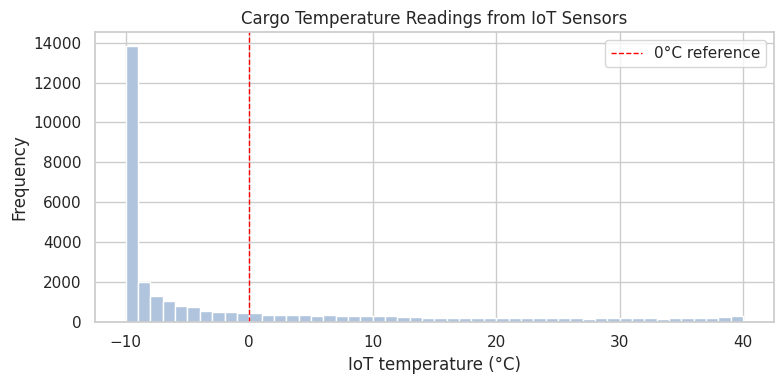

In [27]:
# Step 10a — IoT temperature histogram
plt.figure(figsize=(8, 4))
plt.hist(df['iot_temperature'], bins=50, color='lightsteelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='0°C reference')
plt.xlabel('IoT temperature (°C)')
plt.ylabel('Frequency')
plt.title('Cargo Temperature Readings from IoT Sensors')
plt.legend()
plt.tight_layout()
plt.show()


**Safety note:** Real deployments define product-specific thresholds — never use a single 0°C line for all SKUs.


### Step 10b — Cargo condition vs route risk

**What this cell does:** Scatter of `route_risk_level` (x) vs `cargo_condition_status` (y).

**Fields:**

- `route_risk_level` — geopolitical, infrastructure, or security risk along the path.
- `cargo_condition_status` — 0–1 integrity score (damage, tampering, temperature excursions aggregated).

**Question:** Do high-risk routes correlate with worse cargo condition?

**Expected output:** Scatter — look for downward trend if risk damages cargo handling quality.


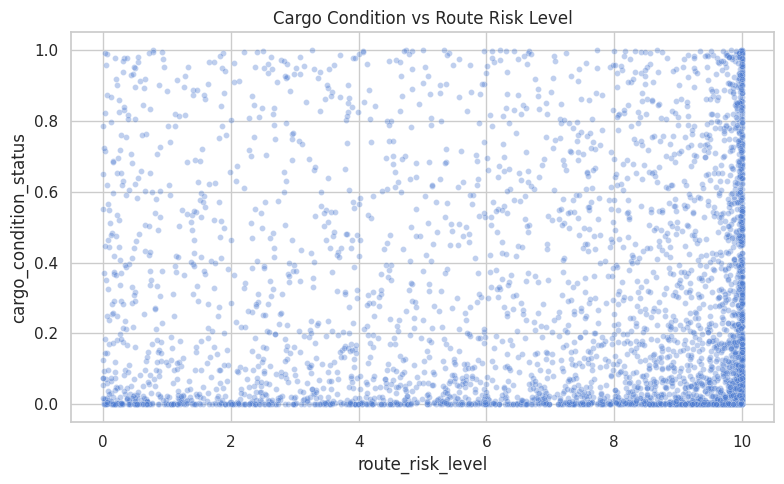

In [28]:
# Step 10b — Cargo condition vs route risk
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='route_risk_level',
    y='cargo_condition_status',
    alpha=0.35,
    s=18,
)
plt.title('Cargo Condition vs Route Risk Level')
plt.tight_layout()
plt.show()


**Use case link:** Insurers and auditors use similar plots to price **cargo policies** and approve lanes.


### Step 10c — Customs clearance time distribution

**What this cell does:** Histogram of `customs_clearance_time` — duration spent in customs processing.

**Why it matters for international lanes:**

- Unexpected customs holds break cold-chain timers.
- Documentation errors show up as long-tail clearance times.

**Expected output:** Right-skewed histogram if most clearances are fast with occasional long delays.


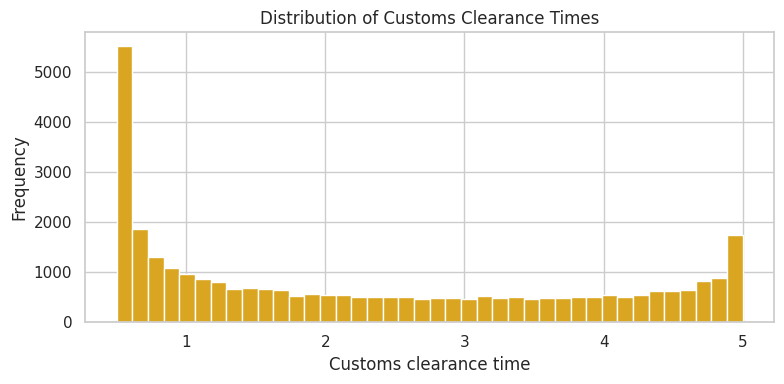

In [29]:
# Step 10c — Customs clearance time
plt.figure(figsize=(8, 4))
plt.hist(df['customs_clearance_time'], bins=40, color='goldenrod', edgecolor='white')
plt.xlabel('Customs clearance time')
plt.ylabel('Frequency')
plt.title('Distribution of Customs Clearance Times')
plt.tight_layout()
plt.show()


**After Part 10:** IoT and customs features matter most for **regulated** supply chains (pharma, food, defense).


---

# Part 11 — Driver behavior and fatigue monitoring

Telematics platforms score **driving style** (harsh braking, speeding) and **fatigue** (hours of service,
camera-based drowsiness). These human-factor metrics complement vehicle and traffic data.


### Step 11a — Driver behavior score distribution

**What this cell does:** Histogram of `driver_behavior_score` across all observations.

**Score interpretation (typical vendor scale):**

- **Near 1.0** — smooth, compliant driving.
- **Near 0.0** — frequent harsh events; may trigger coaching or insurance surcharges.

**Expected output:** Distribution showing how often the fleet operates at each behavior tier.


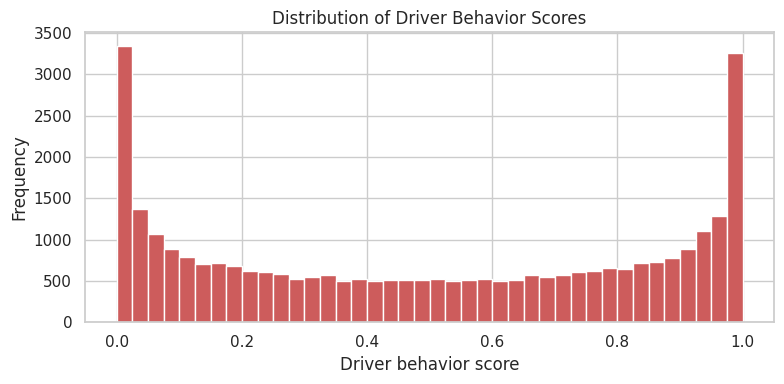

In [30]:
# Step 11a — Driver behavior histogram
plt.figure(figsize=(8, 4))
plt.hist(df['driver_behavior_score'], bins=40, color='indianred', edgecolor='white')
plt.xlabel('Driver behavior score')
plt.ylabel('Frequency')
plt.title('Distribution of Driver Behavior Scores')
plt.tight_layout()
plt.show()


**Fleet safety programs** use this distribution to set coaching thresholds — e.g., flag bottom decile drivers monthly.


### Step 11b — Fatigue score vs delay probability

**What this cell does:** `sns.regplot` of `fatigue_monitoring_score` vs `delay_probability`.

**Hypothesis:** Fatigued drivers may drive slower, take more breaks, or make errors → higher delay risk.

**Caution:** Fatigue score direction varies by vendor (some use higher = more fatigued). Always read vendor docs.

**Expected output:** Scatter with regression trend.


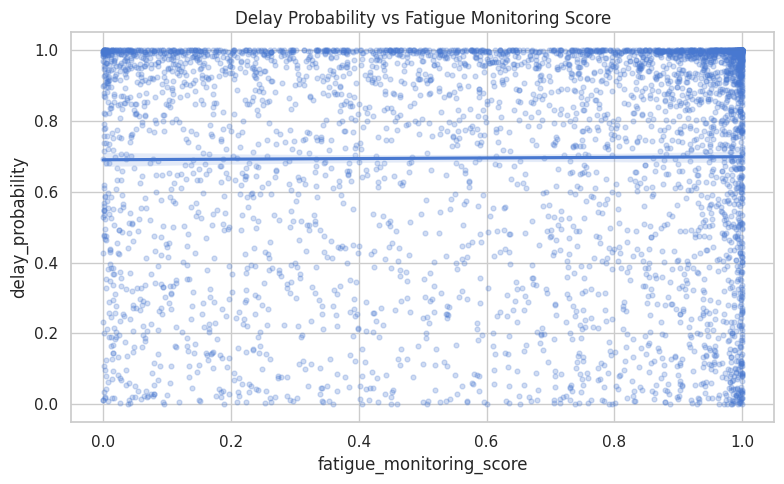

In [31]:
# Step 11b — Fatigue vs delay probability
plt.figure(figsize=(8, 5))
sns.regplot(
    data=plot_sample,
    x='fatigue_monitoring_score',
    y='delay_probability',
    scatter_kws={'alpha': 0.25, 's': 12},
)
plt.title('Delay Probability vs Fatigue Monitoring Score')
plt.tight_layout()
plt.show()


**Policy link:** Hours-of-service regulations exist partly because fatigue-delay relationships are well documented in transport safety research.


---

# Part 12 — Risk scores and classification

This part focuses on **targets** you would predict in ML projects: `risk_classification`,
`disruption_likelihood_score`, and `delay_probability`. Understanding class balance is essential
before training classifiers.


### Step 12a — Risk classification counts

**What this cell does:**

1. Counts rows per `risk_classification` category.
2. Reorders bars: Low → Moderate → High.
3. Plots a bar chart and prints counts.

**Class imbalance warning:** If **High Risk** dominates, accuracy alone is misleading — a naive model
could always predict High Risk and look accurate.

**Better metrics:** F1-score, precision-recall AUC, confusion matrix.

**Expected output:** Bar chart + count Series (~75% High Risk in this dataset).


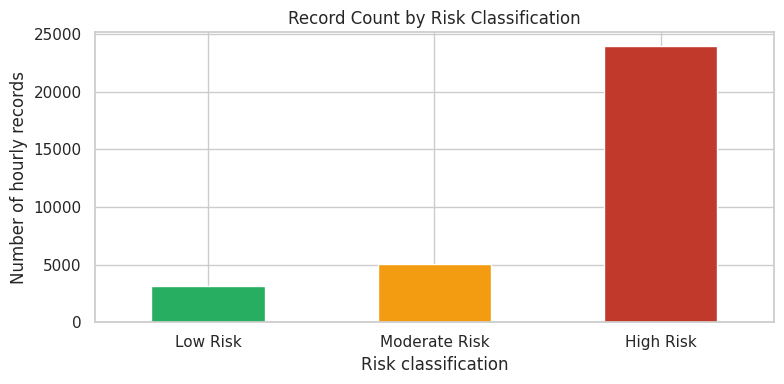

risk_classification
Low Risk          3110
Moderate Risk     5011
High Risk        23944
Name: count, dtype: int64

In [32]:
# Step 12a — Risk classification bar chart
risk_counts = df['risk_classification'].value_counts()
order = ['Low Risk', 'Moderate Risk', 'High Risk']
risk_counts = risk_counts.reindex(order)

plt.figure(figsize=(8, 4))
risk_counts.plot(kind='bar', color=['#27ae60', '#f39c12', '#c0392b'], edgecolor='white')
plt.xlabel('Risk classification')
plt.ylabel('Number of hourly records')
plt.title('Record Count by Risk Classification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
risk_counts


**Teaching moment:** Ask students to compute `% High Risk` = count / 32065. Discuss stratified train/test splits.


### Step 12b — Mean metrics by risk class (heatmap)

**What this cell does:**

1. Selects six risk-related numeric columns.
2. Groups by `risk_classification` and computes means.
3. Displays a **heatmap** (red = high, green = low relative to table).

**How to read the heatmap:**

- Compare **rows** (risk classes) across the same metric.
- High Risk row should show elevated delay, disruption, traffic, etc., if labels are consistent.

**Expected output:** 3×6 annotated heatmap + underlying table.


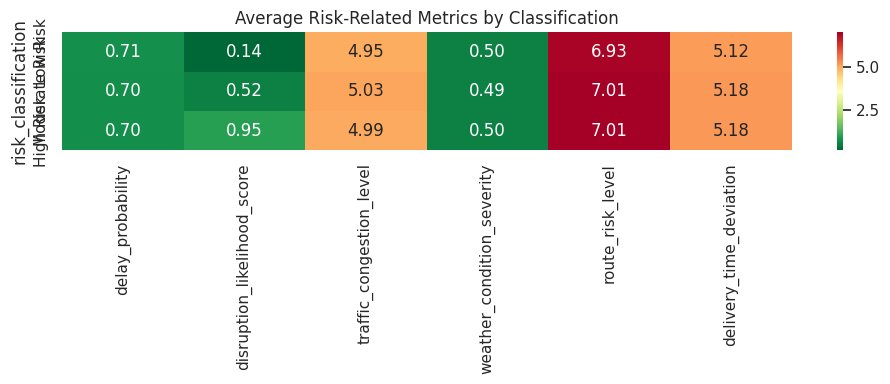

,delay_probability,disruption_likelihood_score,traffic_congestion_level,weather_condition_severity,route_risk_level,delivery_time_deviation
risk_classification,,,,,,
Low Risk,0.707,0.143,4.950,0.503,6.934,5.118
Moderate Risk,0.696,0.519,5.029,0.494,7.005,5.184
High Risk,0.699,0.949,4.989,0.498,7.009,5.184


In [33]:
# Step 12b — Mean metrics by risk class
risk_metrics = [
    'delay_probability',
    'disruption_likelihood_score',
    'traffic_congestion_level',
    'weather_condition_severity',
    'route_risk_level',
    'delivery_time_deviation',
]
risk_summary = df.groupby('risk_classification')[risk_metrics].mean().loc[order]

plt.figure(figsize=(10, 4))
sns.heatmap(risk_summary, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title('Average Risk-Related Metrics by Classification')
plt.tight_layout()
plt.show()
risk_summary


**Validation check:** If Low Risk rows show *higher* mean `delay_probability` than High Risk, label quality
or feature scaling deserves investigation before supervised learning.


### Step 12c — Disruption likelihood vs delay probability

**What this cell does:** Scatter colored by `risk_classification` — combines two composite scores
with the categorical label for visual validation.

**Color key:**

| Color | Class |
|-------|-------|
| Green | Low Risk |
| Orange | Moderate Risk |
| Red | High Risk |

**Expected pattern:** Red points cluster where both disruption and delay scores are high.

**Expected output:** Multi-color scatter plot.


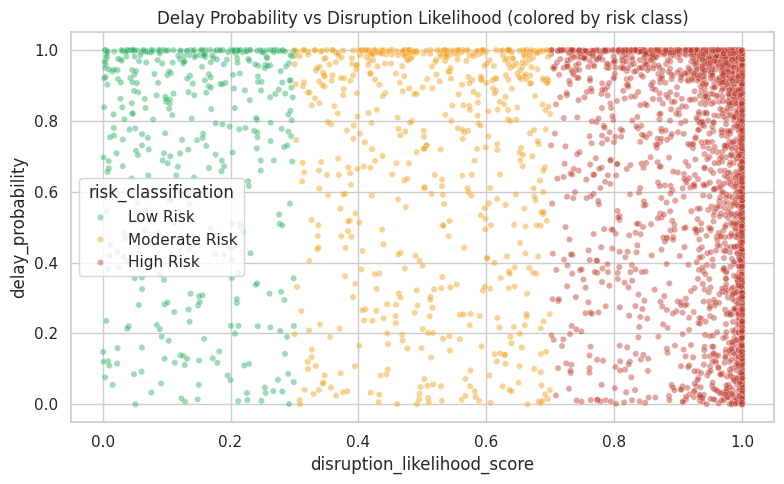

In [34]:
# Step 12c — Disruption vs delay scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='disruption_likelihood_score',
    y='delay_probability',
    hue='risk_classification',
    hue_order=order,
    palette={'Low Risk': '#27ae60', 'Moderate Risk': '#f39c12', 'High Risk': '#c0392b'},
    alpha=0.45,
    s=20,
)
plt.title('Delay Probability vs Disruption Likelihood (colored by risk class)')
plt.tight_layout()
plt.show()


**After Part 12:** You understand label imbalance and how risk classes separate in feature space.
Part 13 zooms out to **all pairwise correlations**.


---

# Part 13 — Correlation overview

Before feature selection for ML, analysts often inspect **correlation matrices** to find redundancy
(two columns measuring the same thing) and strong predictors of outcomes.

> **Caution:** Correlation measures **linear** association only. Non-linear relationships can be missed.
> Correlation does **not** imply causation.


### Step 13a — Correlation heatmap (numeric columns)

**What this cell does:**

1. Selects all numeric dtypes (includes engineered `hour` if present).
2. Computes Pearson correlation matrix.
3. Plots full heatmap with coolwarm colormap (blue = negative, red = positive).

**How to scan a large heatmap:**

- Look for **bright red or blue squares** off the diagonal.
- Check correlations with `delivery_time_deviation` column/row.
- Pairs with |r| > 0.7 may indicate redundant features.

**Expected output:** Large 16×12 figure — zoom in Jupyter or scroll.


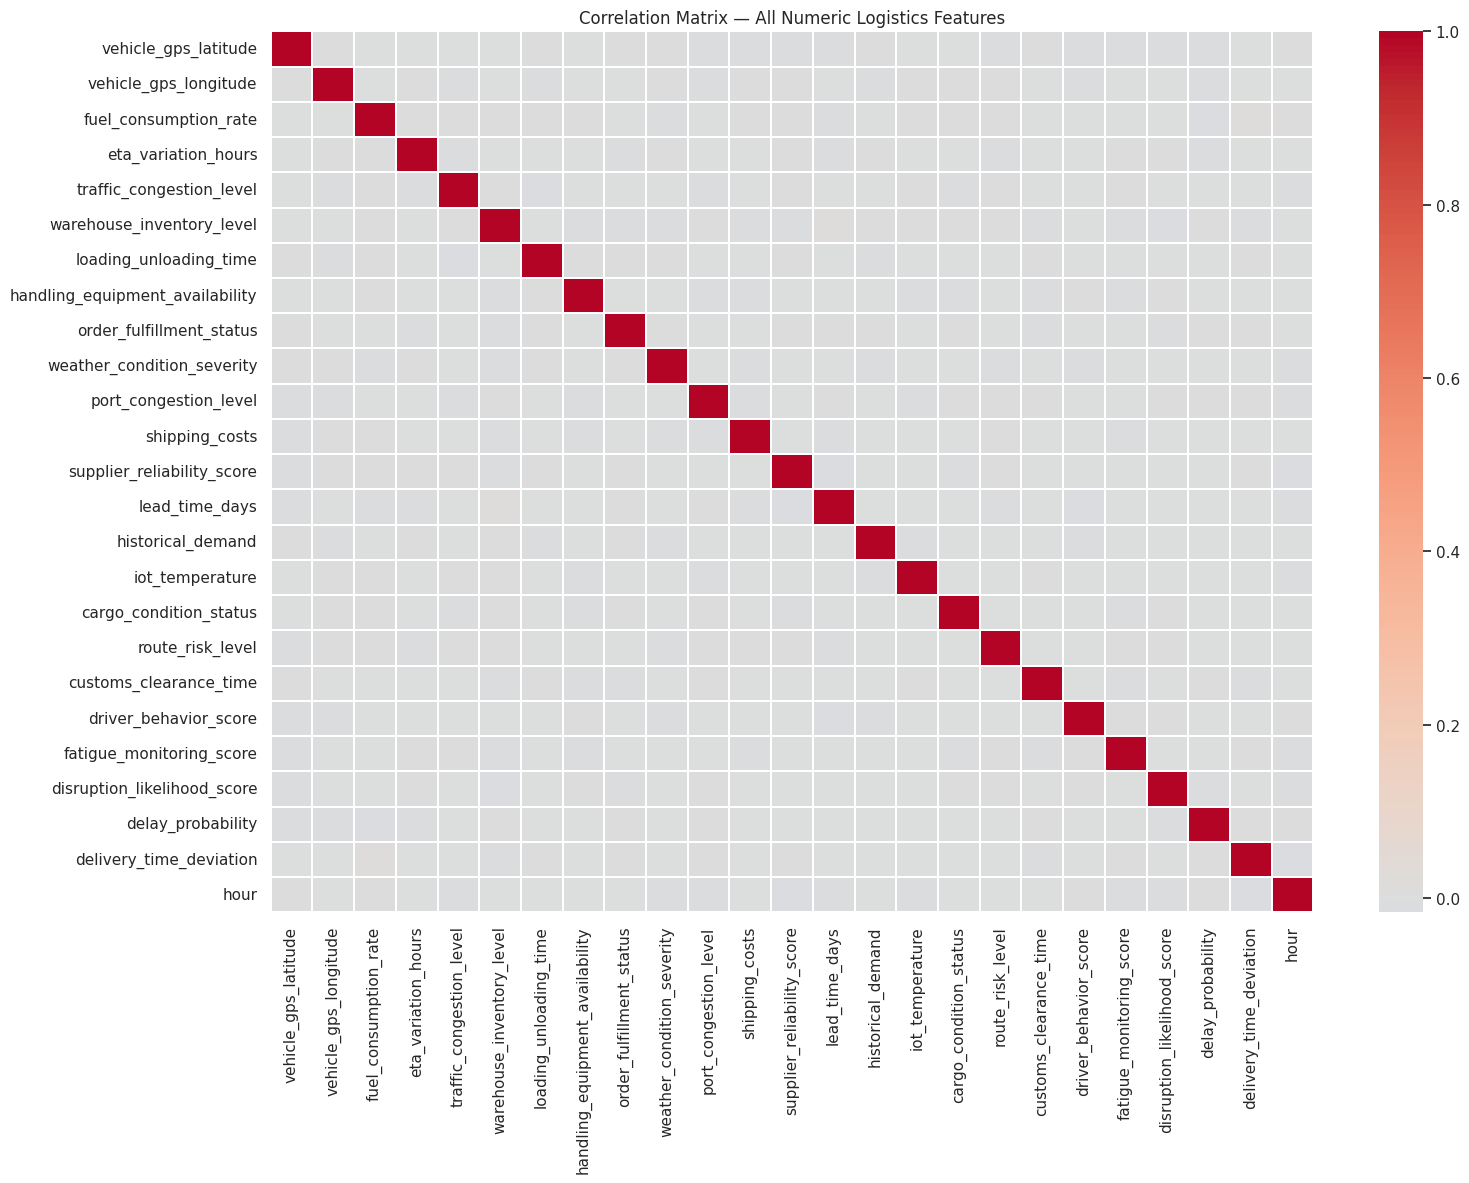

In [35]:
# Step 13a — Correlation heatmap
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Matrix — All Numeric Logistics Features')
plt.tight_layout()
plt.show()


**Tip:** Heatmaps are dense. Step 13b extracts the **top 10** predictors of delivery deviation for a clearer view.


### Step 13b — Top correlations with `delivery_time_deviation`

**What this cell does:**

1. Takes absolute correlation with `delivery_time_deviation`.
2. Drops self-correlation.
3. Keeps top 10 features.
4. Plots horizontal bar chart and prints values.

**Feature selection use:** Columns at the top are promising **regression inputs** (after proper train/test split).

**Expected output:** Bar chart + Series of correlation magnitudes.


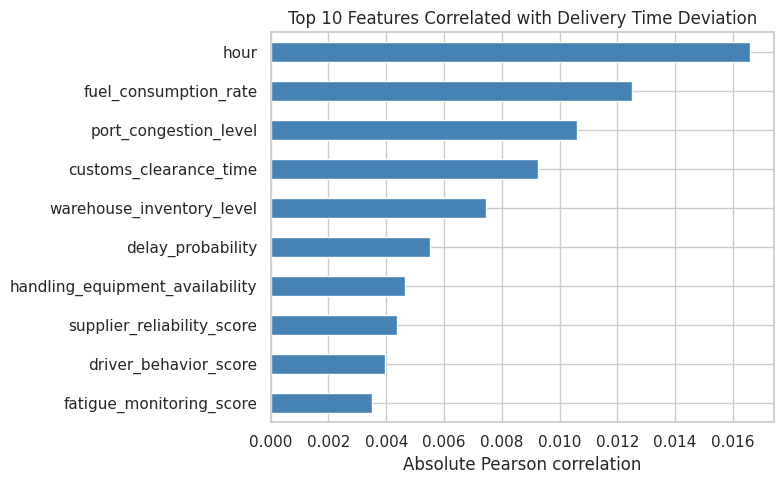

hour                              0.017
fuel_consumption_rate             0.012
port_congestion_level             0.011
customs_clearance_time            0.009
warehouse_inventory_level         0.007
delay_probability                 0.006
handling_equipment_availability   0.005
supplier_reliability_score        0.004
driver_behavior_score             0.004
fatigue_monitoring_score          0.003
Name: delivery_time_deviation, dtype: float64

In [36]:
# Step 13b — Top correlations with delivery deviation
target_corr = (
    corr['delivery_time_deviation']
    .drop('delivery_time_deviation')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
target_corr.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Pearson correlation')
plt.title('Top 10 Features Correlated with Delivery Time Deviation')
plt.tight_layout()
plt.show()
target_corr


**After Part 13:** You completed full EDA — schema, distributions, domain plots, risk labels, and correlations.
Part 14 connects this work to **real-world projects** (reading only).


---

# Part 14 — Real-world use cases (reading & references)

> **No code in this section.** These scenarios show how practitioners apply datasets like this
> after exploratory analysis. Use them to plan capstone projects or Module 8 advanced labs.

## 1. Predictive modeling for risk assessment and disruption detection

**Problem:** Operations teams need early warning before delays cascade to customers.

**How this dataset helps:**

- **Features:** traffic, weather, port congestion, supplier reliability, route risk, fatigue scores.
- **Targets:** `risk_classification`, `disruption_likelihood_score`, `delay_probability`.
- **Techniques:** gradient boosting, random forests, temporal cross-validation by `timestamp`.

**Further reading:**

- [Scikit-learn — Classification overview](https://scikit-learn.org/stable/supervised_learning.html)
- [Imbalanced-learn — Handling class imbalance](https://imbalanced-learn.org/)
- Papers on *supply chain disruption prediction* (search: "machine learning supply chain disruption")

---

## 2. Optimization of routing and scheduling to minimize delays

**Problem:** Given congestion and ETA variation, choose routes and dispatch windows that minimize lateness.

**How this dataset helps:**

- Links **GPS**, **traffic_congestion_level**, and **eta_variation_hours** to **delivery_time_deviation**.
- Supports what-if analysis: simulate rerouting when `port_congestion_level` spikes.

**Further reading:**

- [OR-Tools — Vehicle routing](https://developers.google.com/optimization/routing)
- [VRP literature survey](https://arxiv.org/list/cs.AI/recent) (search "vehicle routing problem")

---

## 3. Predictive maintenance for logistics vehicles

**Problem:** Unplanned breakdowns cause missed SLAs and emergency freight costs.

**How this dataset helps:**

- `fuel_consumption_rate` anomalies may indicate engine or tire issues.
- Combine with mileage and idle time (derived from GPS + timestamp) for maintenance windows.

**Further reading:**

- [Predictive maintenance overview — Microsoft Azure Architecture Center](https://learn.microsoft.com/en-us/azure/architecture/guide/analytics/predictive-maintenance)
- ISO 14224 / fleet telematics vendor docs for sensor standards

---

## 4. Impact of external factors (traffic and weather) on delivery times

**Problem:** Separate controllable delays (dock staffing) from uncontrollable shocks (storms, gridlock).

**How this dataset helps:**

- Compare `weather_condition_severity` and `traffic_congestion_level` against `delivery_time_deviation`.
- Build regression models with interaction terms (weather × region).

**Further reading:**

- [NOAA climate data](https://www.ncei.noaa.gov/) for joining real weather feeds
- [HERE Traffic API](https://developer.here.com/products/traffic) / TomTom Traffic documentation

---

## 5. Enhancing warehouse and inventory management practices

**Problem:** Stockouts and overstocks both hurt margin; equipment bottlenecks slow throughput.

**How this dataset helps:**

- Relate `warehouse_inventory_level`, `historical_demand`, and `order_fulfillment_status`.
- Flag rows where low `handling_equipment_availability` coincides with high `loading_unloading_time`.

**Hands-on in Module 8:** Continue with
`Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb` — builds a Neo4j graph from this CSV.

**Further reading:**

- [Neo4j supply chain use cases](https://neo4j.com/use-cases/supply-chain-management/)
- APICS / CSCP materials on inventory policies (safety stock, reorder points)

---

## 6. Machine learning for logistics efficiency and risk management

**Problem:** Leadership wants a unified analytics layer — forecast, optimize, and monitor risk.

**How this dataset helps:**

- Provides a **realistic feature space** spanning fleet, warehouse, supplier, and risk domains.
- Supports end-to-end workflows: EDA (this notebook) → feature store → train → deploy → monitor drift.

**Further reading:**

- [MLOps overview — Google Cloud](https://cloud.google.com/architecture/mlops-continuous-delivery-and-automation-pipelines-in-machine-learning)
- [Kaggle dataset page](https://www.kaggle.com/datasets/datasetengineer/logistics-and-supply-chain-dataset) — community notebooks and kernels

### Suggested learning path after this notebook

1. **Classification lab** — predict `risk_classification` with scikit-learn.
2. **Regression lab** — predict `delivery_time_deviation`.
3. **Graph lab** — `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb`.
4. **GraphRAG evaluation** — `Module_8_Evaluating_GraphRAG_with_RAGAS.ipynb` (after building a KG).


---

# Part 15 — Wrap-up

## What you learned

| Topic | Takeaway |
|-------|----------|
| Schema | 26 columns across fleet, warehouse, supplier, IoT, and risk domains |
| Time | Hourly records from 2021–2024; strong seasonality and peak-hour effects possible |
| Quality | No missing values in the published CSV; always re-check in production pipelines |
| Risk | Imbalanced `risk_classification`; use appropriate ML metrics (F1, PR-AUC) |
| Relationships | Traffic, weather, and supplier signals co-move with delay and disruption scores |

## Key vocabulary

- **ETA variation** — delta between planned and updated arrival time.
- **Lead time** — supplier days from order to receipt.
- **Fulfillment status** — how completely customer orders are satisfied from stock.
- **Disruption likelihood** — composite operational risk score.

## Check your understanding

1. Name three columns that describe **external** factors outside warehouse control.
2. Which column would you use as a **classification target** for risk triage?
3. Why is class imbalance in `risk_classification` important for model evaluation?
4. How could GPS columns help aggregate metrics by **region**?

## Related Module 8 materials

| Resource | Purpose |
|----------|---------|
| `data/DATASETS.md` | Download instructions and dataset catalog |
| `Module_8_Warehouse_Inventory_Management_with_Knowledge_Graphs.ipynb` | Graph-based warehouse analytics |
| `Module_8_Building_Knowledge_Graphs_with_LLMs.ipynb` | LLM extraction from text corpora |
| `NEO4J_SETUP.md` | Database setup for graph labs |

---

*End of notebook — Exploring the Logistics and Supply Chain Dataset*
